# 01 - EDA

Zindi "To Vaccinate or Not to Vaccinate" tweets. Before building the split and models we want to understand the labels, agreement, lengths and what kind of text we actually have.

Put `Train.csv` and `Test.csv` in `data/` before running.

In [5]:
import os, sys

# on colab clone the repo, locally just move up from notebooks/
if "google.colab" in sys.modules:
    if not os.path.exists("/content/NLP_and_Language_technologies-Group-9"):
        !git clone https://github.com/Samkwizera/NLP_and_Language_technologies-Group-9.git /content/NLP_and_Language_technologies-Group-9
    %cd /content/NLP_and_Language_technologies-Group-9
    !pip install -q -r requirements.txt
    # csvs aren't in git, so copy them from drive (MyDrive/nlp_data/)
    from google.colab import drive
    drive.mount("/content/drive")
    import glob, shutil
    # zindi downloads come as "train (1).csv" etc, the code expects Train.csv / Test.csv
    for f in glob.glob("/content/drive/MyDrive/nlp_data/*.csv"):
        name = os.path.basename(f).lower()
        if name.startswith("train"):
            shutil.copy(f, "data/Train.csv")
        elif name.startswith("test"):
            shutil.copy(f, "data/Test.csv")
    if not os.path.exists("data/Train.csv"):
        raise FileNotFoundError("put the train/test csvs in MyDrive/nlp_data/")
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
os.listdir("data")

/content/NLP_and_Language_technologies-Group-9
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['Test.csv', 'test (1).csv', 'Train.csv', 'README.md', 'train (1).csv']

In [6]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src import preprocessing as pp
from src.utils import set_seed, ensure_dirs

set_seed()
ensure_dirs()
sns.set_theme(style="whitegrid")

ORDER = ["negative", "neutral", "positive"]
FIG = config.FIGURES_DIR

## 1. Loading the files and checking for problems

In [7]:
naive = pd.read_csv(config.TRAIN_CSV, dtype=str, keep_default_na=False)
print(naive.columns.tolist(), naive.shape)
print(naive["label"].value_counts())

bad = ~naive["tweet_id"].str.match(config.TWEET_ID_PATTERN)
idx = naive.index[bad]
naive.loc[sorted(set(idx) | set(idx - 1))]

['tweet_id', 'safe_text', 'label', 'agreement'] (10001, 4)
label
0.0                   4908
1.0                   4053
-1.0                  1038
                         1
0.6666666666666666       1
Name: count, dtype: int64


,tweet_id,safe_text,label,agreement
4798,RQMQ0L2A,#lawandorderSVU,,
4799,I cannot believe in this day and age some pare...,1,0.6666666666666666,


In [8]:
train, train_report = pp.load_train(return_report=True, drop_invalid=False)
test, test_report = pp.load_test(return_report=True)
print(train_report)
print(test_report)

print(train.shape, test.shape)
print(train.isna().sum())
print("empty tweets:", (train["safe_text"].str.strip() == "").sum())
print("invalid rows:", (~train["valid"]).sum())
print("duplicate ids:", train["tweet_id"].duplicated().sum())

train = train[train["valid"]].drop(columns="valid").reset_index(drop=True)
train["label"] = train["label"].astype(int)
train["label_name"] = train["label"].map(config.LABEL_NAMES)

[{'action': 'merged', 'tweet_id': 'RQMQ0L2A', 'text': 'I cannot believe in this day and age some parents could be so oblivious to reality as to not #vaccinate their child.'}]
[{'action': 'orphan', 'tweet_id': None, 'text': 'Dr. JAMES SHANNON'}]
(10000, 5) (5177, 2)
tweet_id     0
safe_text    0
label        0
agreement    0
valid        0
dtype: int64
empty tweets: 0
invalid rows: 0
duplicate ids: 0


The text column is `safe_text` and labels come in as floats (-1.0, 0.0, 1.0), so we cast them to int.

Reading the file normally gives 10,001 rows. One tweet (`RQMQ0L2A`) had a newline in it, so it got split into two rows with the columns shifted, which is where the empty label and the weird "0.667" label come from. We merge it back (label 1, agreement 0.667) instead of dropping it, which leaves 10,000 clean rows with no empty tweets.

Test has one line with no ID ("Dr. JAMES SHANNON"), probably tweet `H0VUUY2P`. It doesn't matter for us since we evaluate on our own split of Train.

Everyone should load data with `pp.load_train()` so we all get the same rows.

## 2. Class distribution

            count  share
label_name              
negative     1038  0.104
neutral      4908  0.491
positive     4054  0.405


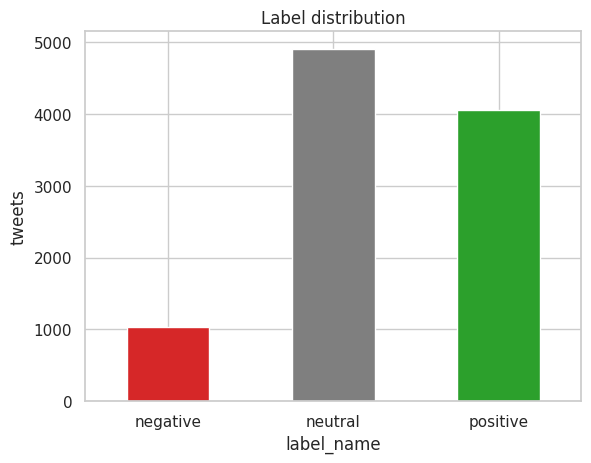

In [9]:
counts = train["label_name"].value_counts().reindex(ORDER)
print(pd.DataFrame({"count": counts, "share": (counts / counts.sum()).round(3)}))

counts.plot.bar(color=["tab:red", "tab:gray", "tab:green"], rot=0)
plt.title("Label distribution")
plt.ylabel("tweets")
plt.savefig(FIG / "eda_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

About 49% neutral, 41% positive and only 10% negative. Negative (anti-vaccine) is the class we care about most and it's the smallest one, so accuracy would look fine even if a model ignored it. That's why we use macro-F1 as the main metric and also report per-class F1.

The split has to be stratified, and we should try class weights for both the baselines and the neural models.

## 3. Annotator agreement

agreement
0.333     239
0.667    3895
1.000    5866
Name: count, dtype: int64
agreement   0.333  0.667  1.000
label_name                     
negative      239    417    382
neutral         0   1748   3160
positive        0   1730   2324
agreement   0.333  0.667  1.000
label_name                     
negative     23.0   40.2   36.8
neutral       0.0   35.6   64.4
positive      0.0   42.7   57.3


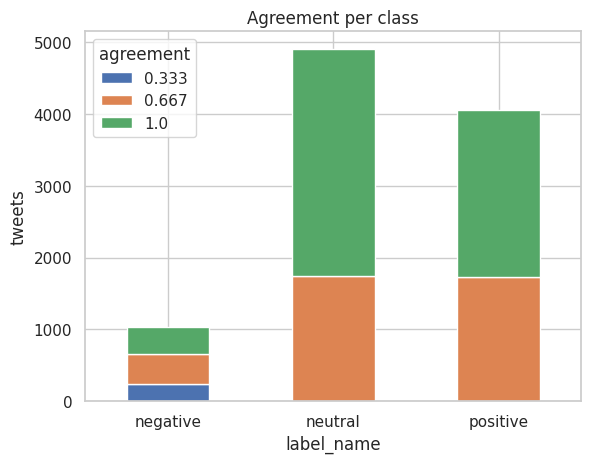

In [10]:
train["agreement"] = train["agreement"].round(3)
print(train["agreement"].value_counts().sort_index())

ct = pd.crosstab(train["label_name"], train["agreement"]).reindex(ORDER)
print(ct)
print((pd.crosstab(train["label_name"], train["agreement"], normalize="index").reindex(ORDER) * 100).round(1))

ct.plot.bar(stacked=True, rot=0)
plt.title("Agreement per class")
plt.ylabel("tweets")
plt.savefig(FIG / "eda_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# how much would we lose if we only trained on agreement == 1?
high = train[train["agreement"] == 1.0]
comp = pd.DataFrame({"all": train["label_name"].value_counts(),
                     "agreement_1": high["label_name"].value_counts()}).reindex(ORDER)
comp["kept_%"] = (comp["agreement_1"] / comp["all"] * 100).round(1)
print(comp)
print(train.loc[train["agreement"] == 0.333, "label_name"].value_counts())

             all  agreement_1  kept_%
label_name                           
negative    1038          382    36.8
neutral     4908         3160    64.4
positive    4054         2324    57.3
label_name
negative    239
Name: count, dtype: int64


59% of tweets have full agreement, 39% have 2 out of 3 annotators agreeing, and 239 tweets (2.4%) have 0.333.

The interesting part is that all 239 of the 0.333 tweets are labelled negative. With 3 annotators, 0.333 means nobody agreed, so it looks like these were just defaulted to -1. That's 23% of the negative class, which is basically label noise. Negative is also the hardest class to agree on (only 37% full agreement vs 64% neutral and 57% positive).

For the agreement experiments:
- all data (baseline)
- only agreement = 1: cleaner, but negatives drop from 1,038 to 382
- dropping only the 0.333 rows, as a middle option
- weighting the loss by agreement

Val and test always keep all rows so the results stay comparable. We will also stratify the split on label and agreement together, so each set gets the same share of these noisy negatives.

## 4. Tweet length

      n_chars  n_tokens
0.50    107.0      20.0
0.90    133.0      27.0
0.95    137.0      29.0
0.99    140.0      33.0
1.00    142.0      50.0
            n_chars  n_tokens
label_name                   
negative      109.0      20.0
neutral       103.0      19.0
positive      111.0      21.0


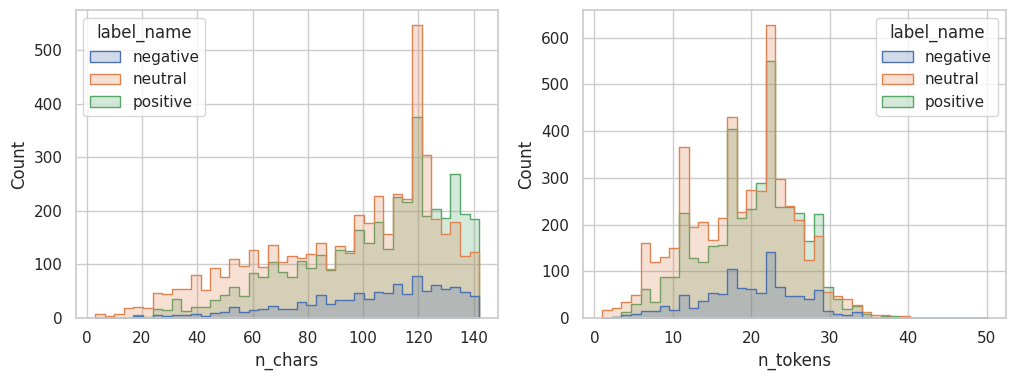

In [12]:
train["n_chars"] = train["safe_text"].map(lambda t: len(pp.normalize(t)))
train["n_tokens"] = train["safe_text"].map(lambda t: len(pp.tokenize(t)))
print(train[["n_chars", "n_tokens"]].quantile([0.5, 0.9, 0.95, 0.99, 1.0]))
print(train.groupby("label_name")[["n_chars", "n_tokens"]].median())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=train, x="n_chars", hue="label_name", hue_order=ORDER, bins=40, element="step", ax=axes[0])
sns.histplot(data=train, x="n_tokens", hue="label_name", hue_order=ORDER, bins=40, element="step", ax=axes[1])
plt.savefig(FIG / "eda_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# subword lengths for the transformers
from transformers import AutoTokenizer

for name in ["cardiffnlp/twitter-roberta-base-sentiment", "xlm-roberta-base"]:
    tok = AutoTokenizer.from_pretrained(name)
    n = train["safe_text"].map(lambda t: len(tok(pp.normalize(t))["input_ids"]))
    print(name, n.quantile([0.5, 0.95, 0.99, 1.0]).tolist())

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

cardiffnlp/twitter-roberta-base-sentiment [28.0, 39.0, 45.0, 129.0]


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

xlm-roberta-base [32.0, 42.0, 47.0, 62.0]


Tweets are short because of the old 140 character limit. The median is about 20 tokens, 99% are under 33 tokens and the longest is 50.

So for the RNN/CNN, max_len = 40 covers basically everything without much padding. For the transformers, 99% of tweets fit in 45 subwords for twitter-roberta and 47 for XLM-R. The longest ones are 129 and 62 (the 129 is emoji heavy, since the byte-level tokenizer splits emojis into several pieces). So max_length = 64 covers over 99% and only cuts a handful of tweets. Length is about the same across classes, so it's not a useful feature on its own.

## 5. Vocabulary

In [14]:
train["words"] = train["safe_text"].map(pp.word_tokens)
vocab = Counter(w for ws in train["words"] for w in ws)
freqs = np.array(list(vocab.values()))
print("vocab size:", len(vocab))
print("words seen once:", (freqs == 1).sum())
print("token coverage with min_freq=2:", round(freqs[freqs >= 2].sum() / freqs.sum(), 3))

vocab size: 11142
words seen once: 5552
token coverage with min_freq=2: 0.96


In [15]:
stop = set("""the a an and or of to in on for is are was were be been it this that with as at by from
i you he she we they my your our their me us them his her its not no so if but just do does did
have has had will would can could should than then there here what who how when why all about rt""".split())

top = {}
for name in ORDER:
    c = Counter(w for ws in train.loc[train["label_name"] == name, "words"] for w in ws if w not in stop)
    top[name] = [w for w, _ in c.most_common(20)]
pd.DataFrame(top)

,negative,neutral,positive
0,vaccine,measles,kids
1,vaccines,health,measles
2,autism,vaccine,vaccinate
3,kids,immunity,vaccine
4,measles,mmr,vaccines
5,children,outbreak,children
6,vaccinations,cases,get
7,vaccinated,people,vaccinated
8,vaccinate,vaccines,autism
9,cause,get,health


In [16]:
# words that are much more common in one class than the others (log-odds, add-1 smoothing)
def distinctive(name, k=15):
    inside = Counter(w for ws in train.loc[train["label_name"] == name, "words"] for w in ws)
    outside = Counter(w for ws in train.loc[train["label_name"] != name, "words"] for w in ws)
    n_in, n_out = sum(inside.values()), sum(outside.values())
    score = {w: np.log((inside[w] + 1) / n_in) - np.log((outside[w] + 1) / n_out)
             for w in vocab if vocab[w] >= 10}
    return sorted(score, key=score.get, reverse=True)[:k]

pd.DataFrame({name: distinctive(name) for name in ORDER})

,negative,neutral,positive
0,fluoride,tension,prevented
1,admits,releasing,psa
2,aluminum,average,irresponsible
3,injured,complain,uneducated
4,injuries,increases,dear
5,forced,boosts,step
6,paralyzed,improves,idiots
7,fda,madhatterdc,preventable
8,scientist,cook,tdap
9,damage,lounge,sky


The vocab is around 11k words and about half of them only show up once (typos, names, pieces of hashtags). For the baselines we'll use min_df=2 plus character n-grams to pick up misspellings. For the RNN we'll use min_freq=2 with an unknown token, and pretrained embeddings (fastText handles rare words better because of subwords).

Topic words like measles, mmr and vaccine are everywhere, so the distinctive words are more useful:
- negative: fluoride, aluminum, injured, paralyzed, mercury, ingredients
- positive: prevented, preventable, protects, but also idiots, uneducated, irresponsible, ignorance
- neutral: restaurant, lounge, cook, tension, releasing (off-topic tweets)

So the label is really stance towards vaccines, not tone. An angry tweet insulting anti-vaxxers is positive. A pretrained sentiment model would probably call those negative, so fine-tuning matters and this is something to look for in the error analysis. Neutral also includes off-topic tweets that just share a keyword.

## 6. Hashtags, emojis, placeholders and leftover URLs/mentions

In [17]:
t = train["safe_text"]
train["hashtags"] = t.map(pp.hashtags)
train["emojis"] = t.map(pp.emojis)

checks = pd.DataFrame({
    "hashtag": train["hashtags"].map(len) > 0,
    "emoji": train["emojis"].map(len) > 0,
    "<user>": t.str.contains("<user>", regex=False),
    "<url>": t.str.contains("<url>", regex=False),
    "leftover url": t.map(lambda s: len(pp.leftover_urls(s)) > 0),
    "leftover @mention": t.map(lambda s: len(pp.leftover_mentions(s)) > 0),
    "html entity": t.str.contains(r"&(?:amp|lt|gt|quot);"),
})
print((checks.mean() * 100).round(1))
print((checks.groupby(train["label_name"]).mean().T * 100).round(1))
print("placeholder counts:", t.str.count("<user>").sum(), t.str.count("<url>").sum())
print(Counter(m for s in t for m in re.findall(r"&\w+;", s)))

hashtag              26.6
emoji                 5.1
<user>               40.4
<url>                43.7
leftover url          0.0
leftover @mention     0.0
html entity           5.9
dtype: float64
label_name         negative  neutral  positive
hashtag                28.0     26.1      26.9
emoji                   2.5      6.5       4.0
<user>                 54.3     38.2      39.5
<url>                  39.6     48.6      38.9
leftover url            0.0      0.0       0.0
leftover @mention       0.0      0.0       0.0
html entity             8.1      5.1       6.4
placeholder counts: 5595 4634
Counter({'&amp;': 597, '&gt;': 59, '&lt;': 38, '&quot;': 3})


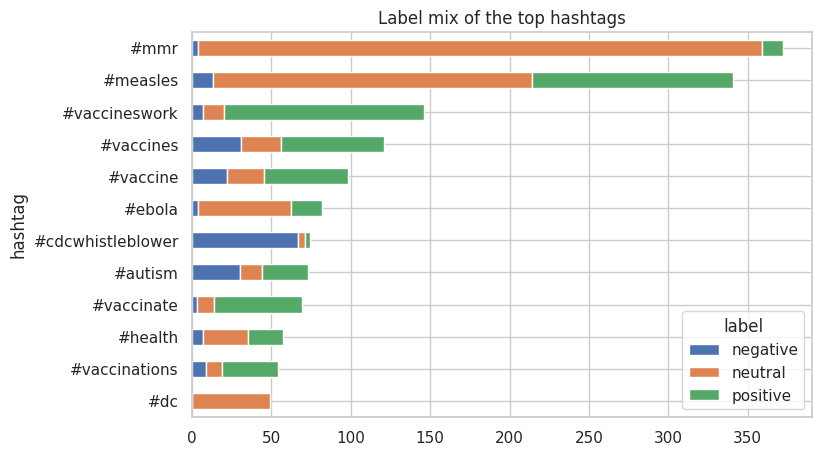

[('😂', 140), ('💉', 63), ('😷', 58), ('🔥', 52), ('😭', 40), ('😳', 39), ('💥', 30), ('😒', 29), ('🙌', 27), ('👏', 25), ('😡', 25), ('😩', 23), ('👍', 20), ('😊', 19), ('😑', 12)]


In [18]:
hc = Counter(h for hs in train["hashtags"] for h in hs)
top_tags = [h for h, _ in hc.most_common(12)]
rows = [(h, lab) for hs, lab in zip(train["hashtags"], train["label_name"]) for h in set(hs)]
tag_df = pd.DataFrame(rows, columns=["hashtag", "label"])
pd.crosstab(tag_df["hashtag"], tag_df["label"]).reindex(top_tags)[ORDER].plot.barh(stacked=True, figsize=(8, 5))
plt.gca().invert_yaxis()
plt.title("Label mix of the top hashtags")
plt.savefig(FIG / "eda_hashtags.png", dpi=150, bbox_inches="tight")
plt.show()

print(Counter(e for es in train["emojis"] for e in es).most_common(15))

- `<user>` (about 5.6k times) and `<url>` (about 4.6k) are the anonymisation placeholders. We keep them as tokens. For the transformers we map them to what each model was trained on (`@user` / `http` for twitter-roberta, `@USER` / `HTTPURL` for BERTweet).
- 54% of negative tweets have a `<user>`, compared to about 38-40% for the other classes, so negative tweets are more often replies or arguments with someone. Neutral tweets have `<url>` more often (49%), which fits news-style tweets sharing a link.
- `&amp;` shows up around 600 times, plus some `&gt;` and `&lt;`. We unescape these, otherwise "amp" becomes one of the top words.
- About a quarter of tweets have hashtags, and some basically give away the label: #cdcwhistleblower is 67/74 negative, #vaccineswork 126/146 positive and #mmr 355/372 neutral. A lot of the #mmr tweets aren't about the vaccine at all. They're music posts (mixtapes, "Jennifair", "DrumMage", #edm), which is why they end up neutral. We keep hashtags, but in the error analysis we should check how models do on tweets without them.
- About 5% of tweets have emojis (the most common are 😂, 💉 and 😷). Negative tweets use them the least (2.5% vs 6.5% for neutral). We keep them.
- There are no leftover URLs or @mentions, so the anonymisation worked.

## 7. Duplicates

In [19]:
train["norm_text"] = t.map(lambda s: pp.normalize(s).lower())
sizes = train.groupby("norm_text").size()
dups = sizes[sizes > 1]
print("duplicate groups:", len(dups), "extra rows:", (dups - 1).sum())

n_labels = train.groupby("norm_text")["label"].nunique()
conflict = n_labels[n_labels > 1].index
print("groups with different labels:", len(conflict))
train[train["norm_text"].isin(conflict)].sort_values("norm_text")[["safe_text", "label_name", "agreement"]].head(15)

duplicate groups: 161 extra rows: 353
groups with different labels: 38


,safe_text,label_name,agreement
4380,.<user> Help save 6m kids' lives. Pledge $1 bi...,positive,1.000
4179,.<user> Help save 6m kids' lives. Pledge $1 bi...,neutral,0.667
1922,.<user> Help save 6m kids' lives. Pledge $1 bi...,positive,0.667
7291,"60,000 Oakland Kids to Get Free Flu Vaccines: ...",positive,0.667
2971,"60,000 Oakland Kids to Get Free Flu Vaccines: ...",neutral,0.667
2220,<user> #GOP STOP blaming #Immigrants first #Eb...,neutral,0.667
2329,<user> #GOP STOP blaming #Immigrants first #Eb...,neutral,1.000
2388,<user> #GOP STOP blaming #Immigrants first #Eb...,neutral,0.667
2614,<user> #GOP STOP blaming #Immigrants first #Eb...,positive,0.667
2675,<user> #GOP STOP blaming #Immigrants first #Eb...,neutral,0.667


161 texts appear more than once (about 353 extra rows, mostly retweets), and 38 of them have different labels on different copies, which is more label noise.

If copies end up in both train and test the scores get inflated, so the split will keep all copies of a text in the same set. We keep the duplicates in training and don't try to fix the conflicting labels.

## 8. Swahili / Sheng / code-switching

The task describes this as Kenyan tweets, so we check how much non-English text there actually is. This is only a rough check: a tweet counts if it has a Swahili/Sheng word from our list, or two different short Swahili words (na, ya, ni...).

In [20]:
train["swahili"] = t.map(pp.is_swahili)
print("flagged:", train["swahili"].sum())
print(train.loc[train["swahili"], "safe_text"].head(20).tolist())

non_ascii = t.map(lambda s: sum(ord(c) > 127 and c.isalpha() for c in s) > 3)
print("tweets with more than 3 non-ascii letters:", non_ascii.sum())

flagged: 1
['En mi TL solo leo mmg, mmr, mmñ, mmgvs entre otras cosas.']
tweets with more than 3 non-ascii letters: 8


In [21]:
# second check: share of words that aren't common English words
from wordfreq import zipf_frequency

def non_english_share(words):
    words = [w for w in words if len(w) > 2]
    if not words:
        return 0.0
    return np.mean([zipf_frequency(w, "en") < 2 for w in words])

train["non_en"] = train["words"].map(non_english_share)
print(train["non_en"].describe())
train.sort_values("non_en", ascending=False)[["safe_text", "non_en"]].head(15)

count    10000.000000
mean         0.015895
std          0.060740
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: non_en, dtype: float64


,safe_text,non_en
6555,#InstaFrame #flushot #vaccine #important #Heal...,1.000000
4384,UMF madhatterdc #mmr #edmlife #edm #ultra2014 ...,1.000000
1410,"""Catios"". 😂 #MMR",1.000000
3188,<user> じゃあMMRってもしかして…,1.000000
6873,🔥🔥🔥 <user> #mmr #somage #jennifair #studio #he...,1.000000
8384,#MMR Jennifair #NewYork #Chicago #Mixtape <url>,1.000000
6670,#MogulintheMaking #followdatbag djhpnotiq #MMR...,1.000000
7445,病院実習行くのにMMRと水疱瘡の抗体を調べたら$550の請求が来た。\n((((；ﾟДﾟ))...,1.000000
1304,Downloadingg #MMR mixtapee !(:,1.000000
1264,<user> burda measles Salgını başladı CA'da tek...,0.888889


There's basically no Swahili or Sheng. Only one tweet gets flagged, and it's Spanish (it matched "leo"). The wordfreq check agrees: the median tweet has 0% non-English words. The tweets at the top of that list are either hashtag-only posts (mostly the #MMR music ones) or a few tweets in Japanese, Spanish and Turkish. Only 8 tweets have more than a few non-ASCII letters. The data is general English vaccine discussion (MMR, measles, Ebola, CDC), not Kenyan code-switched text.

So we don't need any Swahili-specific preprocessing, and English Twitter models (twitter-roberta, BERTweet, GloVe Twitter) make the most sense. The XLM-R / AfroXLMR comparison is still useful, but it becomes "do multilingual models lose anything on English tweets" rather than a code-switching test. We should mention this in the Dataset section of the report.

## Summary

| Finding | What we'll do |
|---|---|
| One tweet split over 2 lines | always load with `pp.load_train()` |
| Only 10% negative | macro-F1, stratified split, try class weights |
| All 239 agreement = 0.333 tweets are negative | agreement experiments: all / agreement = 1 / drop 0.333 / weighted loss, evaluated on full val/test |
| 353 duplicate rows, 38 with conflicting labels | keep copies in the same split |
| 99% of tweets are 33 tokens or fewer | max_len 40 (RNN/CNN), 64 (transformers) |
| Lots of rare words and typos | char n-grams, min_freq=2, pretrained embeddings |
| Placeholders, `&amp;`, hashtags, emojis | unescape HTML, keep the rest |
| Almost no Swahili | English Twitter models first, XLM-R / AfroXLMR as a comparison |

Split for step 2: 70/15/15, seed 42, stratified on label and agreement, with duplicates grouped. The ids get saved to `splits/split_seed42.csv`.